In [248]:
from sympy import *
init_printing()
import matplotlib
import numpy as np
from operator import itemgetter

In [ ]:
alpha, k, beta, a, b = symbols('alpha k beta a b')

In [ ]:
KPcoefficientsMatrix = Matrix([
    [1, 1, -1, -1],
    [1j*(alpha-k), -1j*(alpha + k), -1j*(beta - k), 1j*(beta + k)],
    [exp(1j*(alpha-k)*a), exp(-1j*(alpha + k)*a), -exp(-1j*(beta - k)*b), -exp(1j*(beta + k)*b)],
    [
        1j*(alpha-k)*exp(1j*(alpha-k)*a), 
        -1j*(alpha + k)*exp(-1j*(alpha + k)*a), 
        -1*-1j*(beta - k)*-exp(-1j*(beta - k)*b),
        -1*1j*(beta + k)*-exp(1j*(beta + k)*b)
     ]
])
KPcoefficientsMatrix

⎡              1                                1                             
⎢                                                                             
⎢        1.0⋅ⅈ⋅(α - k)                    -1.0⋅ⅈ⋅(α + k)                    -1
⎢                                                                             
⎢        1.0⋅ⅈ⋅a⋅(α - k)                 -1.0⋅ⅈ⋅a⋅(α + k)                   -1
⎢       ℯ                               ℯ                                 -ℯ  
⎢                                                                             
⎢               1.0⋅ⅈ⋅a⋅(α - k)                  -1.0⋅ⅈ⋅a⋅(α + k)             
⎣1.0⋅ⅈ⋅(α - k)⋅ℯ                 -1.0⋅ⅈ⋅(α + k)⋅ℯ                  -1.0⋅ⅈ⋅(β -

    -1                               -1              ⎤
                                                     ⎥
.0⋅ⅈ⋅(β - k)                   1.0⋅ⅈ⋅(β + k)         ⎥
                                                     ⎥
.0⋅ⅈ⋅b⋅(β - k)                 1.0⋅ⅈ⋅b⋅(β + k)       ⎥
             

In [ ]:
D = KPcoefficientsMatrix.det()

RHS = 0.5*(exp(k*(a+b)) - 1j*exp(k*(a+b)))

In [ ]:
solve(D, RHS)

In [246]:
e = 1.6e-19
b = 2.19e-12
A = 565e-12
d = 2*9.1e-31/((6.6e-34)**2)

In [247]:
print(2*9.1e-31/((6.6e-34)**2))
print(33*9e9*e**2/b)
print(A*sqrt(d))
print(A*sqrt(d)*e)

4.1781450872359966e+36
3.471780821917808e-15
1154888897.45850
1.84782223593360e-10


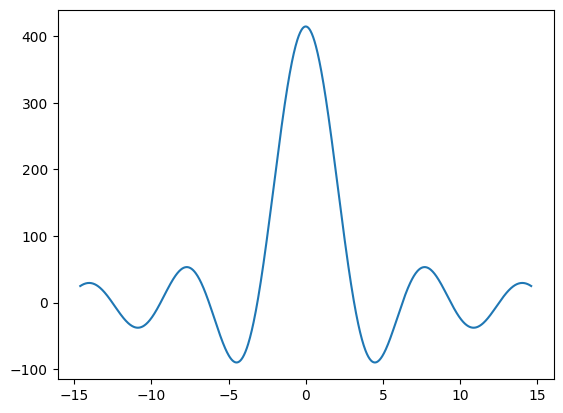

In [252]:
# V = 33*9e9*e**2/b
V = 1e4*e*100
x = np.linspace(float(-sqrt(1000*e)), float(sqrt(1000*e)), 1000) # x = sqrt(E in J)
X = A*sqrt(d)*x

X = X.astype(float)
y = 1*b*A/(2*X)*np.sin((X))*(d*V-1*X**2/(A**2)) + np.cos((X))

# X = np.linspace(-6*np.pi, 6*np.pi, 100)
# y = 1.5*np.pi*np.sin((X))/X + np.cos((X))

# matplotlib.pyplot.plot(x, y)
matplotlib.pyplot.plot(X, y)

In [ ]:
i=np.where((y>0.999) & (y<1.001))
print(i)
(itemgetter(*i)(y)) #469

(array([], dtype=int64),)


array([], dtype=float64)

In [ ]:
E1 = (X[469]/(A*sqrt(d)))**2
print(X[469])
E1/e

2.1687403119440907


22.0401582763945

In [ ]:
print(np.where((y<-0.999)))
(itemgetter(*np.where((y<-0.999)))(y)) #678

(array([678, 679, 680, 681, 682, 683, 684, 685, 686, 687, 688, 689, 690,
       691, 692, 693, 694, 695, 696, 697, 698, 699, 700, 701, 702, 703,
       704, 705, 706, 707, 708, 709, 710, 711, 712, 713, 714, 715, 716,
       717, 718, 719, 720, 721, 722, 723, 724, 725, 726, 727, 728, 729,
       730, 731]),)


array([-0.99917431, -0.99977547, -1.00035338, -1.00090803, -1.00143941,
       -1.00194752, -1.00243237, -1.00289394, -1.00333223, -1.00374725,
       -1.00413899, -1.00450745, -1.00485263, -1.00517454, -1.00547317,
       -1.00574852, -1.0060006 , -1.0062294 , -1.00643494, -1.00661721,
       -1.00677623, -1.00691198, -1.00702448, -1.00711374, -1.00717976,
       -1.00722254, -1.00724209, -1.00723843, -1.00721155, -1.00716147,
       -1.00708819, -1.00699173, -1.00687209, -1.00672928, -1.00656332,
       -1.00637421, -1.00616198, -1.00592662, -1.00566816, -1.0053866 ,
       -1.00508196, -1.00475425, -1.00440349, -1.0040297 , -1.00363289,
       -1.00321307, -1.00277026, -1.00230448, -1.00181574, -1.00130407,
       -1.00076949, -1.000212  , -0.99963164, -0.99902841])

In [ ]:
E2 = (X[678]/(A*sqrt(d)))**2
print(X[678])
E2/e

3.1351938837912448


46.0604748893037

In [ ]:
gap = (E2 - E1)/e
gap

16.3146617692072